In [1]:
from qiskit import __version__

print(__version__)

2.3.1


In [2]:
import numpy as np

from qiskit import QuantumCircuit

from qiskit.visualization import array_to_latex
from qiskit.visualization import plot_histogram

from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator

In [3]:
# np.array([1, 0]) --> That is a 1D array, not explicitly a column vector.

# 2 x 1 mx rep. by a 2D array.
ket0 = np.array([[1], [0]])     

ket1 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)


[[0.5]
 [0.5]]


We can also use array to create matrices that can represent operations.


In [4]:
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])

M = M1 / 2 + M2 / 2

print(M)

[[1.  0.5]
 [0.  0.5]]


Matrix multiplication, including matrix-vector multiplication as a special case, can be performed using the @ operator.

In [5]:
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [6]:
display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
from numpy import sqrt

# Quantum states are column vectors by default.

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])


The Statevector class includes a draw method for displaying state vectors in a variety of ways, including text for plain text, latex for rendered LaTeX, and latex_source for LaTeX code, which can be handy for cutting and pasting into documents. (Use print rather than display to show LaTeX code for best results.)

In [8]:
display(u.draw("text"))
display(u.draw("latex"))
display(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

“Probability density” is used more often in continuous quantum mechanics, like position wavefunctions:
    
ψ(x) where   ∣ψ(x)∣ ^ 2  is a probability density over space.

In quantum computing, since states are usually discrete (∣0⟩,∣1⟩,∣00⟩,…), people mostly just say: amplitudes, probabilities.

The Statevector class also includes the is_valid method, which checks to see if a given vector is a valid quantum state vector (in other words, that it has Euclidean norm equal to 1):

In [9]:
display(u.is_valid())
display(w.is_valid())

True

False

In [10]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

Running the measure method simulates a standard basis measurement. It returns the outcome of that measurement, plus the new quantum state vector of the system after the measurement. (Here we're using Python's print function with an f prefix for formatted printing with embedded expressions.)

In [11]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")

display(state.draw("latex"))

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

Statevector also comes with a sample_counts method that allows for the simulation of any number of measurements on the system, each time starting with a fresh copy of the state.

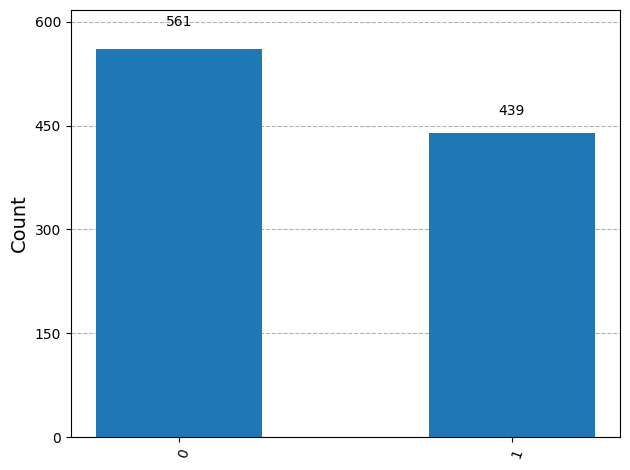

In [24]:
statistics = v.sample_counts(1000)

plot_histogram(statistics)

 With more and more samples, the fraction of samples for each possibility is likely to get closer and closer to the corresponding probability. This phenomenon, more generally speaking, is known as the law of large numbers in probability theory.

The “law of large numbers” is the mathematical idea that repeated random experiments tend to reveal the true underlying probabilities over time 🎲

In [27]:
# Python uses j instead of i mainly to avoid conflict with current i in electrical engineering ⚡

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [29]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

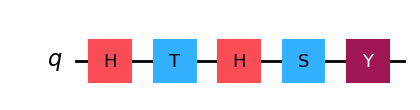

In [34]:
circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

A handy way to get the unitary matrix corresponding to this circuit is to use the from_circuit method from the Operator class.

In [36]:
# Note that the QCt creates the same mx as the Statevector evolved above.
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

In [37]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)

display(v.draw("latex"))

<IPython.core.display.Latex object>

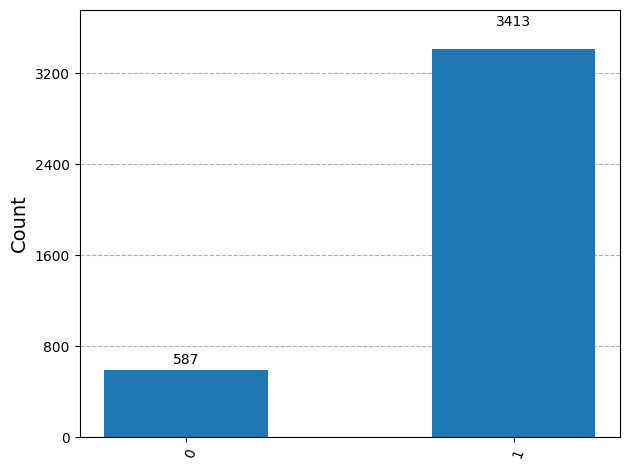

In [38]:
# Simulates an experiment where the state obtained from the circuit above 
# is measured with a standard basis measurement 4000 times (using a fresh copy of the state each time).

statistics2 = v.sample_counts(4000)

display(plot_histogram(statistics2))